This week I want to investigate into why adding noise helps so much, and see if we can find some way, not to have to manually set a noise strength. I also want to look into variable timestepping.

We can analyze the forming of spurious osciallations by using spectral analysis. Suppose we have some function f (in this case our AI model), we input the current timestep $u_i$, so that $f(u_i) = u_{i+1}$ at some point the model will make a small mistake $\delta u$. We can linearize around u to get $f(u_i+\delta u) \approx f(u_i) + J\delta u$ with $J$ the jacobian at $u_i$. Repeatedly applying our model has the effect of multiplying $\delta u$ by powers of $J$. We then diagonalize $J$ and look at its eigenvalues. If the jacobian has eigenvalues with $|\lambda| > 1$, then the rollout can blow up if $\delta u$ has a component in the direction of the eigenvector corresponding to this eigenvalue. Knowing this, we expect a stable AI model to have eigenvalues smaller than 1. Lets now see how noise changes the eigenvalues of the jacobian.

We can see that adding noise shifts the eigenvalues of both models down. Now both models have a nice maximum eigenvalue of just below 1 (this is for a jacobian at u0, other timesteps give very similar results, although sometimes slightly larger than 1). We also see why the flux model was so unstable without adding noise, as it has many modes that will blow up.

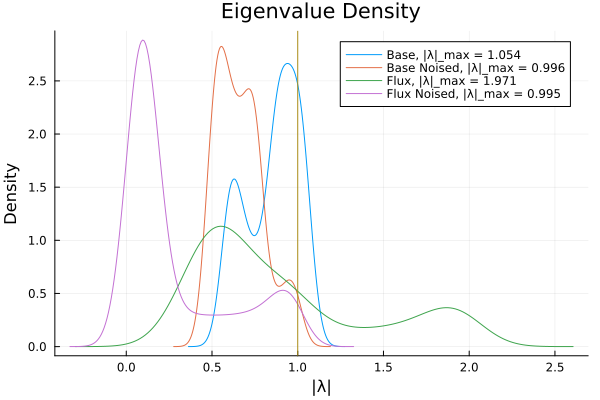

In [2]:
display("image/png", read("media/spectrum_noise.png"))

I should note that these graphs change over time. The above graph is for t=0. Below is one of the density over time for the flux based model without noise.

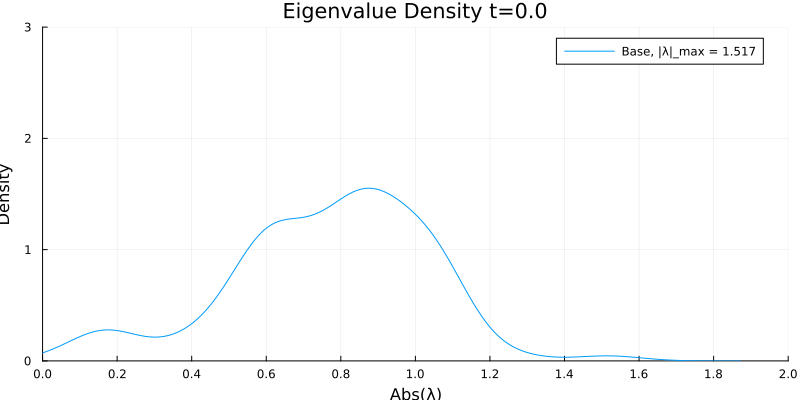

In [4]:
display("image/gif", read("media/TEMP.gif"))

A cool thing that we can now do, is forcing a blow up in models with a largest eigenvalue bigger than 1. All we need to do is add a small $\delta u$ which is the eigenvector corresponding to the largest eigenvalue. We can compare this to a mode with a smaller eigenvalue.

It was quite hard to find an unstable model that didnt blow up by itself. A lot of times a model will have a large maximum eigenvalue at t=0, but smaller at later timesteps, which causes the mode to be supressed. In the second gif, we can also see that our small error caused a small oscillation at a later time, possibly by temporarily striking a high eigenvalue mode.

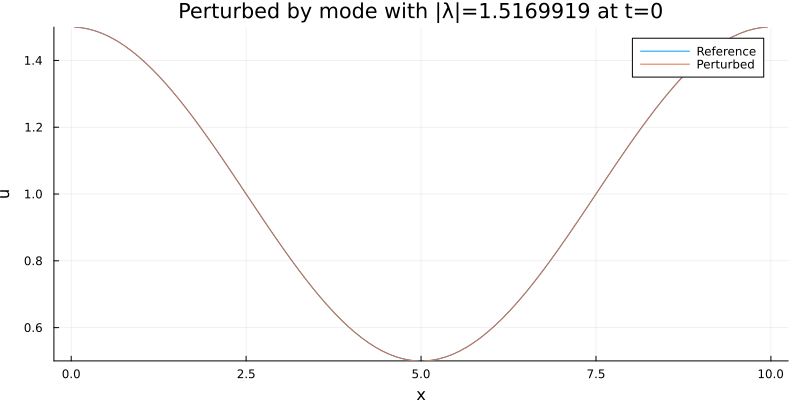

In [6]:
display("image/gif", read("media/forced_blowup.gif"))

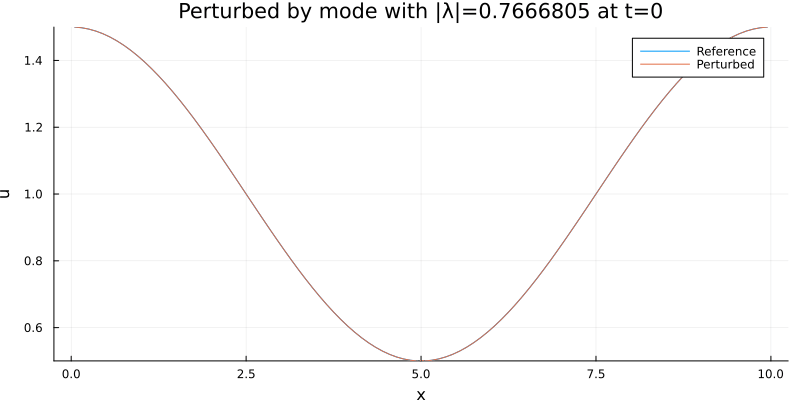

In [7]:
display("image/gif", read("media/small_forced_blowup.gif"))